In [1]:
import copy
import math
import numpy as np
import time
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.colors as colors
import matplotlib.pyplot as plt
from optim import SSBFGS, SSBroyden

In [2]:
# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [3]:
class Net(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.depth = len(layers) - 1
        self.activation = nn.Tanh()

        # Build the network
        layer_list = []
        for i in range(self.depth - 1):
            layer_list.append(nn.Linear(layers[i], layers[i+1]))
            layer_list.append(self.activation)
        layer_list.append(nn.Linear(layers[-2], layers[-1]))

        self.net = nn.Sequential(*layer_list)

    def forward(self, x, y):
        X = torch.cat([x, y], dim=1)
        return self.net(X)

class HardCodeNet(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.depth = len(layers) - 1
        self.activation = nn.Tanh()

        # Build the network
        layer_list = []
        for i in range(self.depth - 1):
            layer_list.append(nn.Linear(layers[i], layers[i+1]))
            layer_list.append(self.activation)
        layer_list.append(nn.Linear(layers[-2], layers[-1]))

        self.net = nn.Sequential(*layer_list)

    def forward(self, x, y):
        X = torch.cat([x, y], dim=1)
        N_out = self.net(X)
        return (1 - x**2 - y**2) * N_out

Now we consider the same issue but in cartesian coordinates
$D = \{(x, y) \in \mathbb{R}^2 \mid x^2 + y^2 < 1\}$
$$
\begin{cases}
    \Delta u = -(x^2 + y^2) & \text{ in } D \\
    u(x, y) = 0 & \text{ on } \partial D
\end{cases}
$$

With a solution $u(x, y) = \frac{1}{16} (1 - x^2 - y^2) (x^2 + y^2 + 1)$

In [4]:
# --- Collocation points ---
N_f = 5000
r_f = torch.rand(N_f, 1)
theta_f = (torch.rand(N_f, 1) - 0.5) * 2 * math.pi
x_f = (r_f * torch.cos(theta_f)).requires_grad_(True)
y_f = (r_f * torch.sin(theta_f)).requires_grad_(True)

f = (-torch.pow(x_f, 2) - torch.pow(y_f, 2)).detach()

# --- Boundary points ---
N_b = 300
theta_bc = torch.rand(N_b, 1)*2*math.pi - math.pi
x_b = torch.cos(theta_bc)
y_b = torch.sin(theta_bc)

# --- Exact solution at interior collocation points ---
u_exact_train = (1/16 *(1 - torch.pow(x_f, 2) - torch.pow(y_f, 2)) * (torch.pow(x_f, 2) + torch.pow(y_f, 2) + 1)).detach()
l2_relative_error = {}
mse = {}
l_inf_error = {}

In [5]:
def compute_loss(net, name=""):
    # Wipe the input gradients inside the closure!
    if x_f.grad is not None: x_f.grad.zero_()
    if y_f.grad is not None: y_f.grad.zero_()

    # --- Compute the PDE residual ---
    u_f = net(x_f, y_f)
    u_x = torch.autograd.grad(u_f.sum(), x_f, create_graph=True)[0]
    u_y = torch.autograd.grad(u_f.sum(), y_f ,create_graph=True)[0]

    u_xx = torch.autograd.grad(u_x, x_f, torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y_f, torch.ones_like(u_y), create_graph=True)[0]
    residual = u_xx + u_yy - f
    loss_pde = torch.mean(residual**2)

    # --- Compute the boundary loss ---
    if name == "Standard":
        u_b_pred = net(x_b, y_b)
        loss_bc = torch.mean(u_b_pred**2)
        loss_pde += loss_bc

    return loss_pde

def record_metrics(net, name):
    # Disable gradients just for metric calculation to save memory/time
    with torch.no_grad():
        u_f = net(x_f, y_f)
        diff = u_f - u_exact_train

        l2_relative_error[name].append((torch.norm(diff) / torch.norm(u_exact_train)).item())
        mse[name].append(torch.mean(diff ** 2).item())
        l_inf_error[name].append(torch.max(torch.abs(diff)).item())

        plateau_mse = False
        if len(mse[name]) > 100:
            window = mse[name][-100:]
            rel_spread = (max(window) - min(window)) / (min(window) + 1e-12)
            plateau_mse = rel_spread < 1e-4

        return plateau_mse

In [6]:
# --- Initialize the network ---
layers = [2, 20, 20, 1]
adamNet = Net(layers)
adamOptimizer = optim.Adam(adamNet.parameters(), lr=1e-3)

l2_relative_error["Standard"] = []
mse["Standard"] = []
l_inf_error["Standard"] = []

# --- Training loop ---
adam_epochs = 5000
quasi_newton_epochs = 10000
start = time.time()
for epoch in range(adam_epochs+quasi_newton_epochs):
    adamOptimizer.zero_grad()
    loss = compute_loss(adamNet, "Standard")
    # --- Backpropagation ---
    loss.backward()
    adamOptimizer.step()

    # Record metrics exactly once per epoch
    plateau = record_metrics(adamNet, 'Standard')
    if plateau:
        break

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6e}")

print(f'Training completed in {time.time() - start:.2f} seconds')

Epoch 0, Loss: 2.637921e-01
Epoch 500, Loss: 4.133941e-03
Epoch 1000, Loss: 2.858953e-04
Epoch 1500, Loss: 1.212630e-04
Epoch 2000, Loss: 7.726115e-05
Epoch 2500, Loss: 5.614377e-05
Epoch 3000, Loss: 4.286921e-05
Epoch 3500, Loss: 3.255143e-05
Epoch 4000, Loss: 2.479080e-05
Epoch 4500, Loss: 1.641931e-05
Epoch 5000, Loss: 1.123541e-05
Epoch 5500, Loss: 8.335208e-06
Epoch 6000, Loss: 1.118844e-05
Epoch 6500, Loss: 4.170955e-06
Epoch 7000, Loss: 3.247942e-06
Epoch 7500, Loss: 2.704476e-06
Epoch 8000, Loss: 2.211189e-06
Epoch 8500, Loss: 1.940675e-06
Epoch 9000, Loss: 1.751898e-06
Epoch 9500, Loss: 1.555334e-06
Epoch 10000, Loss: 2.711361e-06
Epoch 10500, Loss: 3.936614e-06
Epoch 11000, Loss: 1.216551e-06
Epoch 11500, Loss: 3.736648e-06
Epoch 12000, Loss: 5.823391e-05
Epoch 12500, Loss: 2.541230e-06
Epoch 13000, Loss: 9.478275e-07
Epoch 13500, Loss: 1.041772e-06
Epoch 14000, Loss: 6.113150e-06
Epoch 14500, Loss: 5.305846e-06
Training completed in 135.62 seconds


In [7]:
hcAdamNet = HardCodeNet(layers)

l2_relative_error["HCAdam"] = []
mse["HCAdam"] = []
l_inf_error["HCAdam"] = []

# --- Stage 1: Adam Optimizer (Initialization) ---
print("Stage 1: Pre-training with Adam...")
hcAdamOptimizer = optim.Adam(hcAdamNet.parameters(), lr=1e-3)

start = time.time()
for epoch in range(adam_epochs):
    hcAdamOptimizer.zero_grad()
    loss = compute_loss(hcAdamNet)
    loss.backward()
    hcAdamOptimizer.step()

    # Record metrics exactly once per epoch
    plateau = record_metrics(hcAdamNet, 'HCAdam')
    if plateau:
        break

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6e}")

adam_time = time.time() - start

Stage 1: Pre-training with Adam...
Epoch 0, Loss: 7.337923e-01
Epoch 500, Loss: 1.900306e-03
Epoch 1000, Loss: 1.073852e-03
Epoch 1500, Loss: 6.442916e-04
Epoch 2000, Loss: 3.775575e-04
Epoch 2500, Loss: 1.935220e-04
Epoch 3000, Loss: 8.523367e-05
Epoch 3500, Loss: 4.347687e-05
Epoch 4000, Loss: 1.960863e-05
Epoch 4500, Loss: 1.098793e-05


In [8]:
stdLBFGSNet = copy.deepcopy(hcAdamNet) # Experiment 2
l2_relative_error["std"] = l2_relative_error["HCAdam"][:]
mse["std"] = mse["HCAdam"][:]
l_inf_error["std"] = l_inf_error["HCAdam"][:]

sqrtLBFGSNet = copy.deepcopy(hcAdamNet) # Experiment 3
l2_relative_error["sqrt"] = l2_relative_error["HCAdam"][:]
mse["sqrt"] = mse["HCAdam"][:]
l_inf_error["sqrt"] = l_inf_error["HCAdam"][:]

logLBFGSNet = copy.deepcopy(hcAdamNet) # Experiment 4
l2_relative_error["log"] = l2_relative_error["HCAdam"][:]
mse["log"] = mse["HCAdam"][:]
l_inf_error["log"] = l_inf_error["HCAdam"][:]

sSBFGSNet = copy.deepcopy(hcAdamNet) # Experiment 5
l2_relative_error["ssbfgs"] = l2_relative_error["HCAdam"][:]
mse["ssbfgs"] = mse["HCAdam"][:]
l_inf_error["ssbfgs"] = l_inf_error["HCAdam"][:]

sSBroydenNet = copy.deepcopy(hcAdamNet) # Experiment 6
l2_relative_error["ssbroyden"] = l2_relative_error["HCAdam"][:]
mse["ssbroyden"] = mse["HCAdam"][:]
l_inf_error["ssbroyden"] = l_inf_error["HCAdam"][:]

In [9]:
# --- EXPERIMENT 1: Continue with Adam (No LBFGS) ---
print("Exp 1: Continuing Adam...")
start = time.time()
for epoch in range(quasi_newton_epochs):
    hcAdamOptimizer.zero_grad()
    loss = compute_loss(hcAdamNet)
    loss.backward()
    hcAdamOptimizer.step()

    # Record metrics exactly once per epoch
    plateau = record_metrics(hcAdamNet, 'HCAdam')
    if plateau:
        break

    if epoch % 500 == 0:
        print(f"Epoch {epoch},  Loss: {loss.item():.6e}")

print(f"Total time Adam: {adam_time + time.time() - start:.2f} seconds")

Exp 1: Continuing Adam...
Epoch 0,  Loss: 9.172791e-06
Epoch 500,  Loss: 8.188746e-06
Epoch 1000,  Loss: 7.390133e-06
Epoch 1500,  Loss: 6.680098e-06
Epoch 2000,  Loss: 6.089178e-06
Epoch 2500,  Loss: 5.622267e-06
Epoch 3000,  Loss: 5.216969e-06
Epoch 3500,  Loss: 7.307272e-06
Epoch 4000,  Loss: 3.373612e-05
Epoch 4500,  Loss: 4.412378e-06
Epoch 5000,  Loss: 5.154812e-06
Epoch 5500,  Loss: 4.087321e-06
Epoch 6000,  Loss: 3.922621e-06
Epoch 6500,  Loss: 1.859463e-04
Epoch 7000,  Loss: 1.074912e-05
Epoch 7500,  Loss: 4.072906e-06
Epoch 8000,  Loss: 3.470022e-06
Epoch 8500,  Loss: 3.365105e-06
Epoch 9000,  Loss: 3.273865e-06
Epoch 9500,  Loss: 1.539666e-04
Total time Adam: 155.02 seconds


In [10]:
# --- EXPERIMENT 2: Standard LBFGS (Minimize MSE) ---
print("Exp 2: Standard LBFGS (MSE)...")
stdOptimizer = optim.LBFGS(
    stdLBFGSNet.parameters(),
    lr=1.0,
    max_iter=1,
    max_eval=20,
    history_size=100,  # Large history ~ full BFGS
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe"
)

start = time.time()
for epoch in range(quasi_newton_epochs):
    def closure_std():
        stdOptimizer.zero_grad()
        loss = compute_loss(stdLBFGSNet) # Standard Loss
        loss.backward()
        return loss

    # Take ONE step (the line search happens silently inside here)
    loss_val = stdOptimizer.step(closure_std)

    # Record metrics exactly once per successful step
    plateau = record_metrics(stdLBFGSNet, 'std')
    if plateau:
        break

    if epoch % 500 == 0:
        print(f"L-BFGS Epoch {epoch}, Loss: {loss_val.item():.6e}")

lbfgs_time = adam_time + time.time() - start
print(f"Total time (Adam + LBFGS): {lbfgs_time:.2f} seconds")

Exp 2: Standard LBFGS (MSE)...
L-BFGS Epoch 0, Loss: 9.172791e-06
Total time (Adam + LBFGS): 60.07 seconds


In [11]:
# --- EXPERIMENT 3: Modified LBFGS (Minimize Sqrt(MSE)) ---
print("Exp 3: Modified LBFGS (J_1/2)...")
sqrtOptimizer = optim.LBFGS(
    sqrtLBFGSNet.parameters(),
    lr=1.0,
    max_iter=1,
    max_eval=20,
    history_size=100,  # Large history ~ full BFGS
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe"
)

start = time.time()
for epoch in range(quasi_newton_epochs):
    def closure_sqrt():
        sqrtOptimizer.zero_grad()
        loss_mse = compute_loss(sqrtLBFGSNet)
        loss_sqrt = torch.sqrt(loss_mse)
        loss_sqrt.backward()
        return loss_sqrt

    # Take ONE step (the line search happens silently inside here)
    loss_val = sqrtOptimizer.step(closure_sqrt)

    # Record metrics exactly once per successful step
    plateau = record_metrics(sqrtLBFGSNet, 'sqrt')
    if plateau:
        break

    if epoch % 500 == 0:
        print(f"L-BFGS Epoch {epoch}, Loss: {math.pow(loss_val.item(), 2):.6e}")

sqrt_time = adam_time + time.time() - start
print(f"Total time (Adam + sqrt LBFGS): {sqrt_time:.2f} seconds")

Exp 3: Modified LBFGS (J_1/2)...
L-BFGS Epoch 0, Loss: 9.172790e-06
L-BFGS Epoch 500, Loss: 6.483267e-08
Total time (Adam + sqrt LBFGS): 68.39 seconds


In [12]:
# --- EXPERIMENT 4: Modified LBFGS (Minimize log(MSE)) ---
print("Exp 4: Modified LBFGS (log(J))...")
logOptimizer = optim.LBFGS(
    logLBFGSNet.parameters(),
    lr=1.0,
    max_iter=1,
    max_eval=20,
    history_size=100,  # Large history ~ full BFGS
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe"
)

start = time.time()
for epoch in range(quasi_newton_epochs):
    def closure_log():
        logOptimizer.zero_grad()
        loss_mse = compute_loss(logLBFGSNet)
        loss_log = torch.log(loss_mse)
        loss_log.backward()
        return loss_log

    # Take ONE step (the line search happens silently inside here)
    loss_val = logOptimizer.step(closure_log)

    # Record metrics exactly once per successful step
    plateau = record_metrics(logLBFGSNet, 'log')
    if plateau:
        break

    if epoch % 500 == 0:
        print(f"L-BFGS Epoch {epoch}, Loss: {math.exp(loss_val.item()):.6e}")

log_time = adam_time + time.time() - start
print(f"Total time (Adam + log LBFGS): {log_time:.2f} seconds")

Exp 4: Modified LBFGS (log(J))...
L-BFGS Epoch 0, Loss: 9.172791e-06
L-BFGS Epoch 500, Loss: 5.344454e-08
Total time (Adam + log LBFGS): 71.20 seconds


In [13]:
# --- EXPERIMENT 5: Modified BFGS (SSBFGS) ---
print("Exp 5: SSBFGS...")
ssbfgsOptimizer = SSBFGS(
    sSBFGSNet.parameters(),
    lr=1.0,
    max_iter=1,
    max_eval=20,
    history_size=100,  # Large history ~ full BFGS
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe"
)

start = time.time()
for epoch in range(quasi_newton_epochs):
    def closure_ssbfgs():
        ssbfgsOptimizer.zero_grad()
        loss = compute_loss(sSBFGSNet)
        loss.backward()
        return loss

    # Take ONE step (the line search happens silently inside here)
    loss_val = ssbfgsOptimizer.step(closure_ssbfgs)

    # Record metrics exactly once per successful step
    plateau = record_metrics(sSBFGSNet, 'ssbfgs')
    if plateau:
        break

    if epoch % 500 == 0:
        print(f"SSBFGS Epoch {epoch}, Loss: {loss_val.item():.6e}")

ssbfgs_time = adam_time + time.time() - start
print(f"Total time (Adam + SSBFGS): {ssbfgs_time:.2f} seconds")

Exp 5: SSBFGS...
SSBFGS Epoch 0, Loss: 9.171896e-06
SSBFGS Epoch 500, Loss: 4.749267e-11
Total time (Adam + SSBFGS): 101.93 seconds


In [14]:
# --- EXPERIMENT 6: Modified Broyden (SSBroyden) ---
print("Exp 6: SSBroyden...")
ssbroydenOptimizer = SSBroyden(
    sSBroydenNet.parameters(),
    lr=1.0,
    max_iter=1,
    max_eval=20,
    history_size=100,  # Large history ~ full BFGS
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe"
)

start = time.time()
for epoch in range(quasi_newton_epochs):
    def closure_ssbroyden():
        ssbroydenOptimizer.zero_grad()
        loss = compute_loss(sSBroydenNet)
        loss.backward()
        return loss

    # Take ONE step (the line search happens silently inside here)
    loss_val = ssbroydenOptimizer.step(closure_ssbroyden)

    # Record metrics exactly once per successful step
    plateau = record_metrics(sSBroydenNet, 'ssbroyden')
    if plateau:
        break

    if epoch % 500 == 0:
        print(f"SSBroyden Epoch {epoch}, Loss: {loss_val.item():.6e}")

ssbroyden_time = adam_time + time.time() - start
print(f"Total time (Adam + SSBroyden): {ssbroyden_time:.2f} seconds")

Exp 6: SSBroyden...
SSBroyden Epoch 0, Loss: 9.171896e-06
SSBroyden Epoch 500, Loss: 2.342753e-11
Total time (Adam + SSBroyden): 160.42 seconds


In [15]:
# --- Visualization ---
r = torch.linspace(0, 1, 100)
theta = torch.linspace(-np.pi, np.pi, 100)
x = r * torch.cos(theta)
y = r * torch.sin(theta)
R, T = torch.meshgrid(r, theta, indexing='ij')

# Compute Cartesian coordinates only if your network expects (x,y) inputs
X = R * torch.cos(T)
Y = R * torch.sin(T)
X_flat = X.reshape(-1, 1)
Y_flat = Y.reshape(-1, 1)

with torch.no_grad():
    u_pred = adamNet(X_flat, Y_flat).reshape(100,100)
    u_pred_hc = hcAdamNet(X_flat, Y_flat).reshape(100,100)
    u_pred_std = stdLBFGSNet(X_flat, Y_flat).reshape(100, 100)
    u_pred_sqrt = sqrtLBFGSNet(X_flat, Y_flat).reshape(100, 100)
    u_pred_log = logLBFGSNet(X_flat, Y_flat).reshape(100, 100)
    u_pred_ssbfgs = sSBFGSNet(X_flat, Y_flat).reshape(100, 100)
    u_pred_ssbroyden = sSBroydenNet(X_flat, Y_flat).reshape(100, 100)
    u_exact_vis = 1/16 *(1 - R**2) * (R**2 + 1)

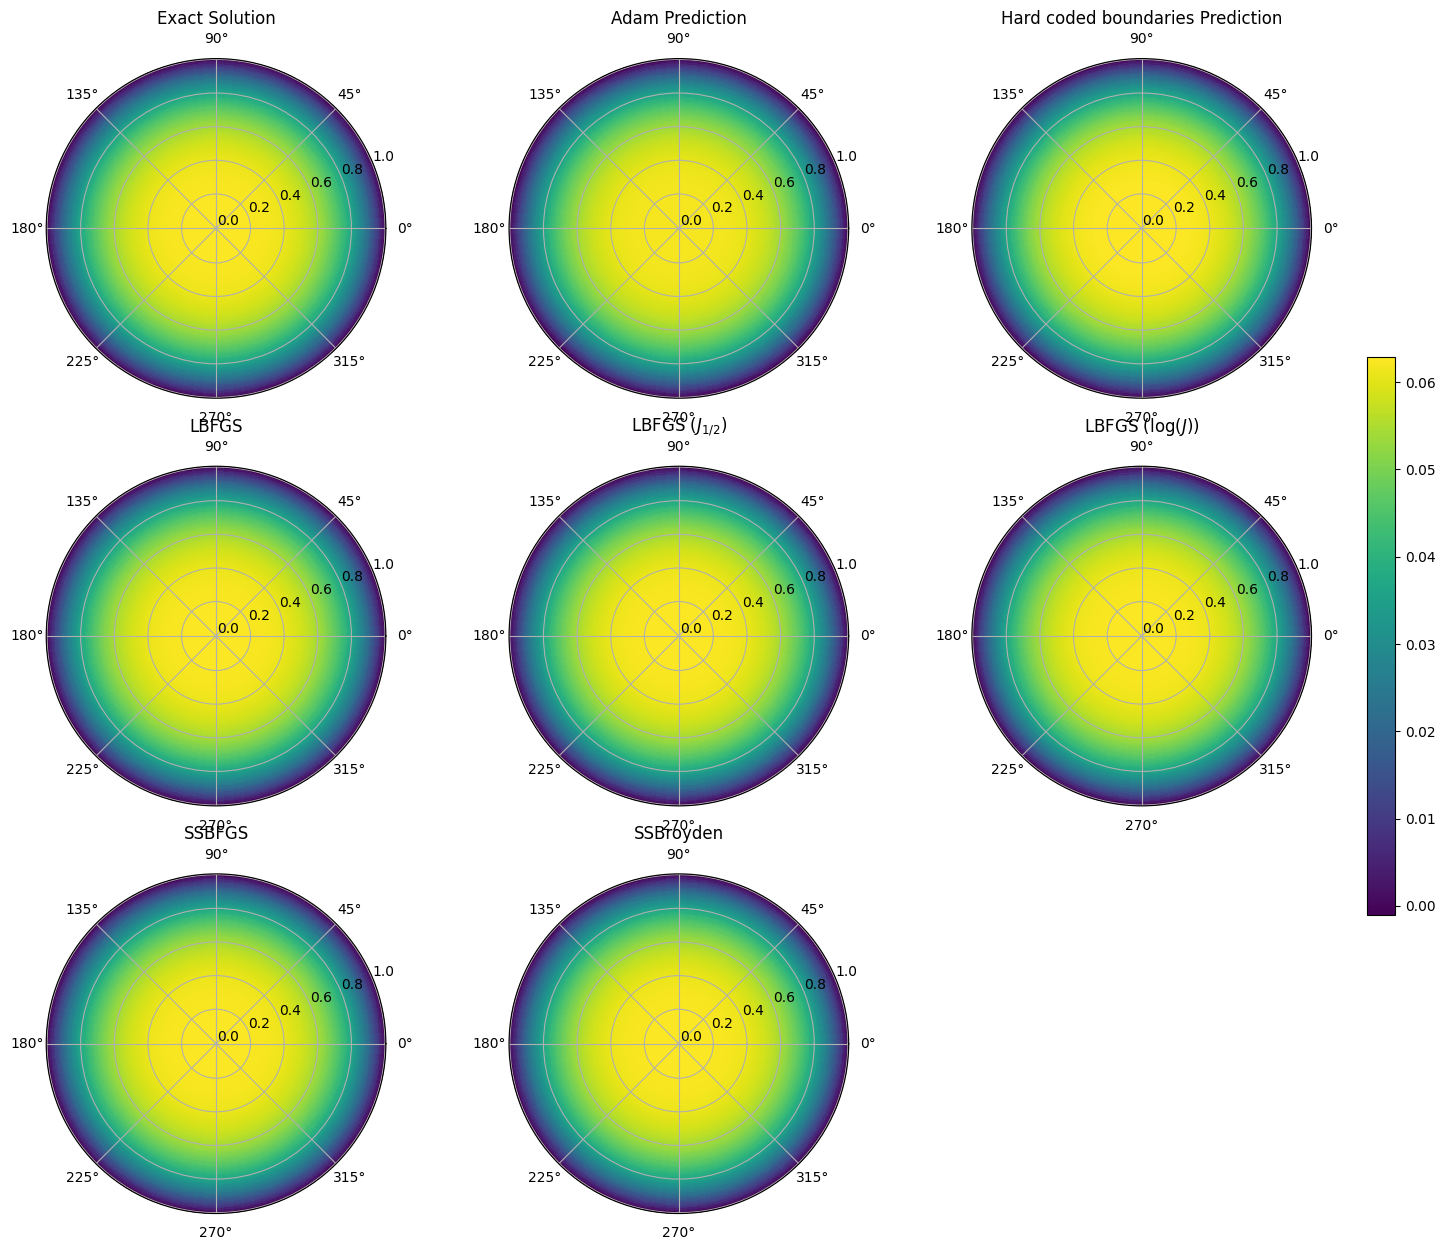

In [16]:
all_data = [u_exact_vis, u_pred, u_pred_hc, u_pred_std, u_pred_sqrt, u_pred_log, u_pred_ssbfgs, u_pred_ssbroyden]
vmin = min(d.min() for d in all_data)
vmax = max(d.max() for d in all_data)

fig = plt.figure(figsize=(18,15))

# Exact solution
plt.subplot(3,3,1, projection='polar')
im = plt.pcolormesh(T, R, u_exact_vis, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title('Exact Solution')

# PINN prediction
plt.subplot(3,3,2, projection='polar')
plt.pcolormesh(T, R, u_pred, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title('Adam Prediction')

# Hard coded boundaries prediction
plt.subplot(3,3,3, projection='polar')
plt.pcolormesh(T, R, u_pred_hc, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title('Hard coded boundaries Prediction')

# Standard LBFGS prediction
plt.subplot(3,3,4, projection='polar')
plt.pcolormesh(T, R, u_pred_std, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title('LBFGS')

# Sqrt LBFGS prediction
plt.subplot(3,3,5, projection='polar')
plt.pcolormesh(T, R, u_pred_sqrt, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title(r'LBFGS ($J_{1/2}$)')

# Log LBFGS prediction
plt.subplot(3,3,6, projection='polar')
plt.pcolormesh(T, R, u_pred_log, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title(r'LBFGS ($\log(J)$)')

# SSBFGS prediction
plt.subplot(3,3,7, projection='polar')
plt.pcolormesh(T, R, u_pred_ssbfgs, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title(r'SSBFGS')

# SSBroyden prediction
plt.subplot(3,3,8, projection='polar')
plt.pcolormesh(T, R, u_pred_ssbroyden, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title(r'SSBroyden')

fig.colorbar(im, ax=fig.get_axes(), orientation='vertical', fraction=0.02, pad=0.04)

plt.show()

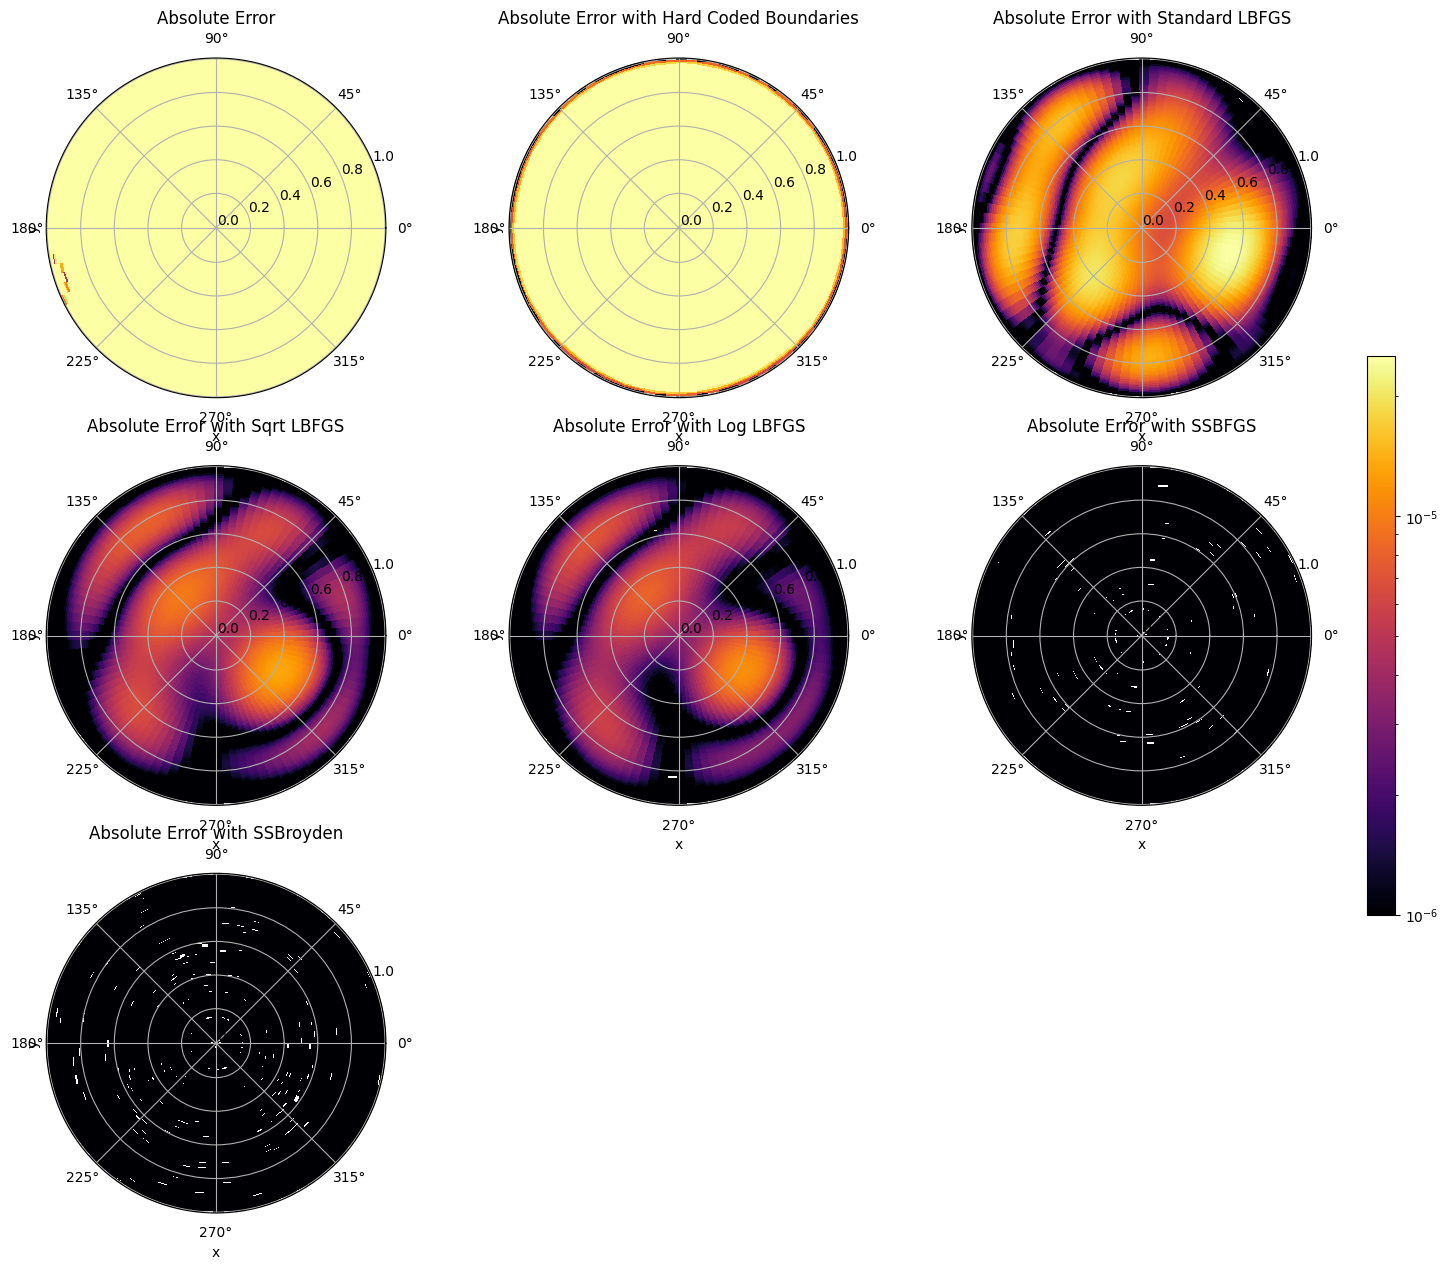

In [17]:
err_adam = torch.abs(u_pred - u_exact_vis)
err_hc = torch.abs(u_pred_hc - u_exact_vis)
err_std  = torch.abs(u_pred_std - u_exact_vis)
err_sqrt = torch.abs(u_pred_sqrt - u_exact_vis)
err_log  = torch.abs(u_pred_log - u_exact_vis)
err_ssbfgs = torch.abs(u_pred_ssbfgs - u_exact_vis)
err_ssbroyden  = torch.abs(u_pred_ssbroyden - u_exact_vis)

all_errors = [err_std, err_sqrt, err_log, err_ssbfgs, err_ssbroyden]
vmin = 1e-6
vmax = max(e.max() for e in all_errors)

fig = plt.figure(figsize=(18,15))

plt.subplot(3,3,1, projection='polar')
im = plt.pcolormesh(T, R, err_adam, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin, vmax=vmax))
plt.title('Absolute Error')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(3,3,2, projection='polar')
plt.pcolormesh(T, R, err_hc, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin, vmax=vmax))
plt.title('Absolute Error with Hard Coded Boundaries')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(3,3,3, projection='polar')
plt.pcolormesh(T, R, err_std, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin, vmax=vmax))
plt.title('Absolute Error with Standard LBFGS')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(3,3,4, projection='polar')
plt.pcolormesh(T, R, err_sqrt, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin, vmax=vmax))
plt.title('Absolute Error with Sqrt LBFGS')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(3,3,5, projection='polar')
plt.pcolormesh(T, R, err_log, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin, vmax=vmax))
plt.title('Absolute Error with Log LBFGS')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(3,3,6, projection='polar')
plt.pcolormesh(T, R, err_ssbfgs, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin, vmax=vmax))
plt.title('Absolute Error with SSBFGS')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(3,3,7, projection='polar')
plt.pcolormesh(T, R, err_ssbroyden, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin, vmax=vmax))
plt.title('Absolute Error with SSBroyden')
plt.xlabel('x')
plt.ylabel('y')

fig.colorbar(im, ax=fig.get_axes(), orientation='vertical', fraction=0.02, pad=0.04)

plt.show()

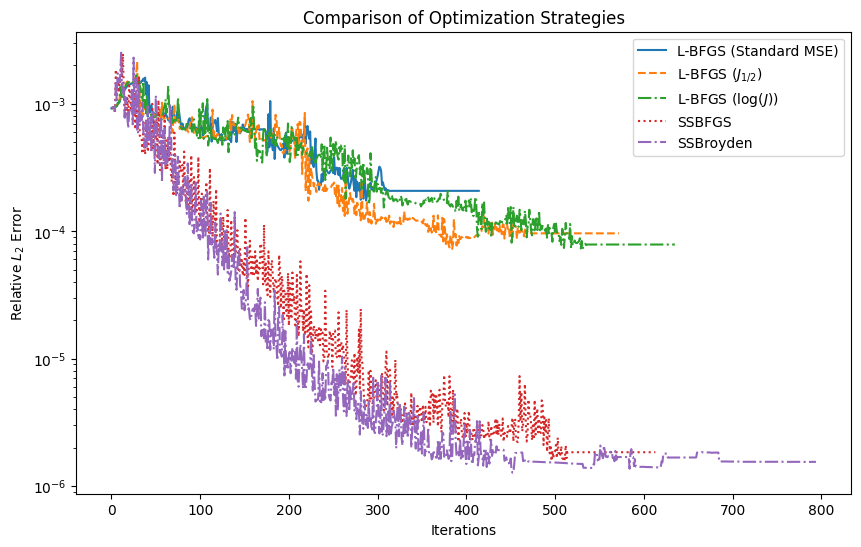

In [26]:
# --- PLOTTING ---
plt.figure(figsize=(10, 6))

# plt.semilogy(l2_relative_error["Standard"], label='Adam') # Exp 1: More Adam
# plt.semilogy(l2_relative_error["HCAdam"], label='Hard Coded Boundaries') # Exp 1: More Adam
plt.semilogy(l2_relative_error["std"][adam_epochs:], label='L-BFGS (Standard MSE)') # Exp 2: Standard LBFGS
plt.semilogy(l2_relative_error["sqrt"][adam_epochs:], label=r'L-BFGS ($J_{1/2}$)', linestyle='--')
plt.semilogy(l2_relative_error["log"][adam_epochs:], label=r'L-BFGS ($\log(J)$)', linestyle='-.')
plt.semilogy(l2_relative_error["ssbfgs"][adam_epochs:], label='SSBFGS', linestyle=':')
plt.semilogy(l2_relative_error["ssbroyden"][adam_epochs:], label='SSBroyden', linestyle='-.')

plt.xlabel('Iterations')
plt.ylabel(r'Relative $L_2$ Error')
plt.title('Comparison of Optimization Strategies')
plt.legend()
plt.show()

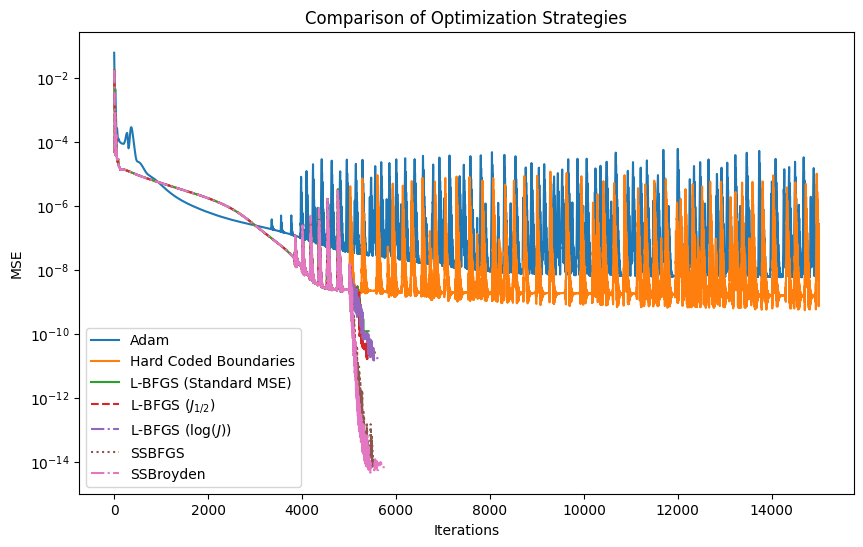

In [25]:
# --- PLOTTING ---
plt.figure(figsize=(10, 6))

plt.semilogy(mse["Standard"], label='Adam') # Exp 1: More Adam
plt.semilogy(mse["HCAdam"], label='Hard Coded Boundaries') # Exp 1: More Adam
plt.semilogy(mse["std"], label='L-BFGS (Standard MSE)') # Exp 2: Standard LBFGS
plt.semilogy(mse["sqrt"], label=r'L-BFGS ($J_{1/2}$)', linestyle='--')
plt.semilogy(mse["log"], label=r'L-BFGS ($\log(J)$)', linestyle='-.')
plt.semilogy(mse["ssbfgs"], label='SSBFGS', linestyle=':')
plt.semilogy(mse["ssbroyden"], label='SSBroyden', linestyle='-.')

plt.xlabel('Iterations')
plt.ylabel('MSE')
plt.title('Comparison of Optimization Strategies')
plt.legend()
plt.show()

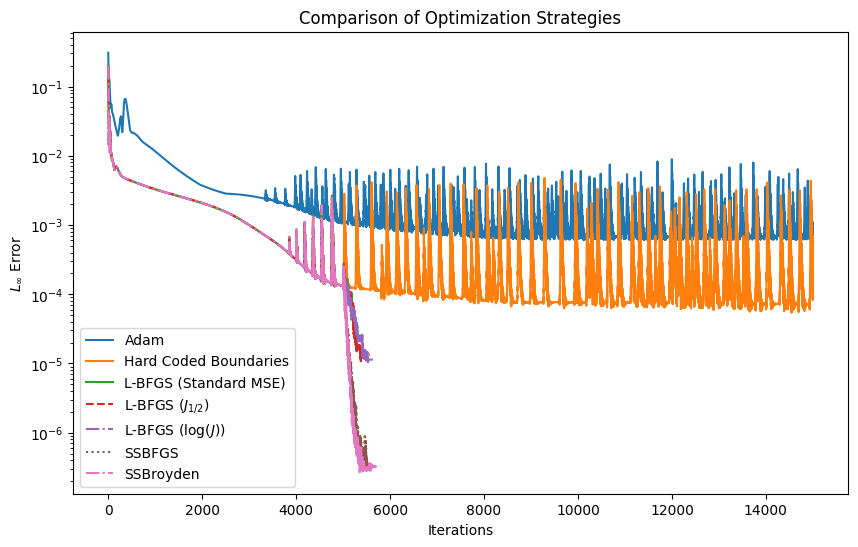

In [20]:
# --- PLOTTING ---
plt.figure(figsize=(10, 6))

plt.semilogy(l_inf_error["Standard"], label='Adam') # Exp 1: More Adam
plt.semilogy(l_inf_error["HCAdam"], label='Hard Coded Boundaries') # Exp 1: More Adam
plt.semilogy(l_inf_error["std"], label='L-BFGS (Standard MSE)') # Exp 2: Standard LBFGS
plt.semilogy(l_inf_error["sqrt"], label=r'L-BFGS ($J_{1/2}$)', linestyle='--')
plt.semilogy(l_inf_error["log"], label=r'L-BFGS ($\log(J)$)', linestyle='-.')
plt.semilogy(l_inf_error["ssbfgs"], label='SSBFGS', linestyle=':')
plt.semilogy(l_inf_error["ssbroyden"], label='SSBroyden', linestyle='-.')

plt.xlabel('Iterations')
plt.ylabel(r'$L_{\infty}$ Error')
plt.title('Comparison of Optimization Strategies')
plt.legend()
plt.show()

In [21]:
l2_relative_adam = torch.norm(err_adam) / torch.norm(u_exact_vis)
l2_relative_hc = torch.norm(err_hc) / torch.norm(u_exact_vis)
l2_relative_std = torch.norm(err_std) / torch.norm(u_exact_vis)
l2_relative_sqrt = torch.norm(err_sqrt) / torch.norm(u_exact_vis)
l2_relative_log = torch.norm(err_log) / torch.norm(u_exact_vis)
l2_relative_ssbfgs = torch.norm(err_ssbfgs) / torch.norm(u_exact_vis)
l2_relative_ssbroyden = torch.norm(err_ssbroyden) / torch.norm(u_exact_vis)

print("Relative L2 Error:")
print(f"Adam: {l2_relative_adam:.6e}")
print(f"HC Boundaries: {l2_relative_hc:.6e}")
print(f"LBFGS: {l2_relative_std:.6e}")
print(f"LBFGS J_1/2: {l2_relative_sqrt:.6e}")
print(f"LBFGS log(J): {l2_relative_log:.6e}")
print(f"SSBFGS: {l2_relative_ssbfgs:.6e}")
print(f"SSBroyden: {l2_relative_ssbroyden:.6e}")

Relative L2 Error:
Adam: 9.877932e-03
HC Boundaries: 5.255370e-03
LBFGS: 2.077330e-04
LBFGS J_1/2: 9.497845e-05
LBFGS log(J): 7.755140e-05
SSBFGS: 1.879666e-06
SSBroyden: 1.547065e-06


In [22]:
mse_adam = torch.mean(err_adam ** 2)
mse_hc = torch.mean(err_hc ** 2)
mse_std = torch.mean(err_std ** 2)
mse_sqrt = torch.mean(err_sqrt ** 2)
mse_log = torch.mean(err_log ** 2)
mse_ssbfgs = torch.mean(err_ssbfgs ** 2)
mse_ssbroyden = torch.mean(err_ssbroyden ** 2)


print("MSE:")
print(f"Adam: {mse_adam:.6e}")
print(f"HC Boundaries: {mse_hc:.6e}")
print(f"LBFGS: {mse_std:.6e}")
print(f"LBFGS J_1/2: {mse_sqrt:.6e}")
print(f"LBFGS log(J): {mse_log:.6e}")
print(f"SSBFGS: {mse_ssbfgs:.6e}")
print(f"SSBroyden: {mse_ssbroyden:.6e}")

MSE:
Adam: 2.702320e-07
HC Boundaries: 7.649113e-08
LBFGS: 1.195130e-10
LBFGS J_1/2: 2.498353e-11
LBFGS log(J): 1.665646e-11
SSBFGS: 9.785131e-15
SSBroyden: 6.628610e-15


In [23]:
l_inf_adam = torch.max(torch.abs(err_adam))
l_inf_hc = torch.max(torch.abs(err_hc))
l_inf_std = torch.max(torch.abs(err_std))
l_inf_sqrt = torch.max(torch.abs(err_sqrt))
l_inf_log = torch.max(torch.abs(err_log))
l_inf_ssbfgs = torch.max(torch.abs(err_ssbfgs))
l_inf_ssbroyden = torch.max(torch.abs(err_ssbroyden))


print("L_inf error:")
print(f"Adam: {l_inf_adam:.6e}")
print(f"HC Boundaries: {l_inf_hc:.6e}")
print(f"LBFGS: {l_inf_std:.6e}")
print(f"LBFGS J_1/2: {l_inf_sqrt:.6e}")
print(f"LBFGS log(J): {l_inf_log:.6e}")
print(f"SSBFGS: {l_inf_ssbfgs:.6e}")
print(f"SSBroyden: {l_inf_ssbroyden:.6e}")

L_inf error:
Adam: 1.064301e-03
HC Boundaries: 3.830716e-04
LBFGS: 2.514943e-05
LBFGS J_1/2: 1.337007e-05
LBFGS log(J): 1.139566e-05
SSBFGS: 3.650784e-07
SSBroyden: 3.203750e-07
